>>> Loading raw data from GitHub...
>>> Phase 1: Global search (Nelder-Mead)...
>>> Phase 2: Precision refinement (L-BFGS-B)...

WILL RELATIONAL GEOMETRY: FULL OPTICAL + ROMER SOLUTION
Fit Quality (Chi-Squared):       727.2044
Number of Observables:           174
-----------------------------------------------------------------
Relational Beta (beta):          0.00642627
Angular Semi-major Axis (a_as):  0.124120 arcsec
Eccentricity (e):                0.887171
Inclination (i):                 2.377080 rad
Argument of Periapsis (omega):   1.162905 rad
Period (T):                      5862.4861 days
Derived Precession (f_prec):     0.00058183
Systemic Velocity (V0):          -15.5462 km/s
-----------------------------------------------------------------
DERIVED PHYSICAL PARAMETERS (FROM T and BETA ONLY):
Schwarzschild Radius (Rs):       12827524.71 km
Semi-major Axis (a):             1038.173191 AU
Distance to Sgr A* (R0):         8364.24 pc
----------------------------------------------

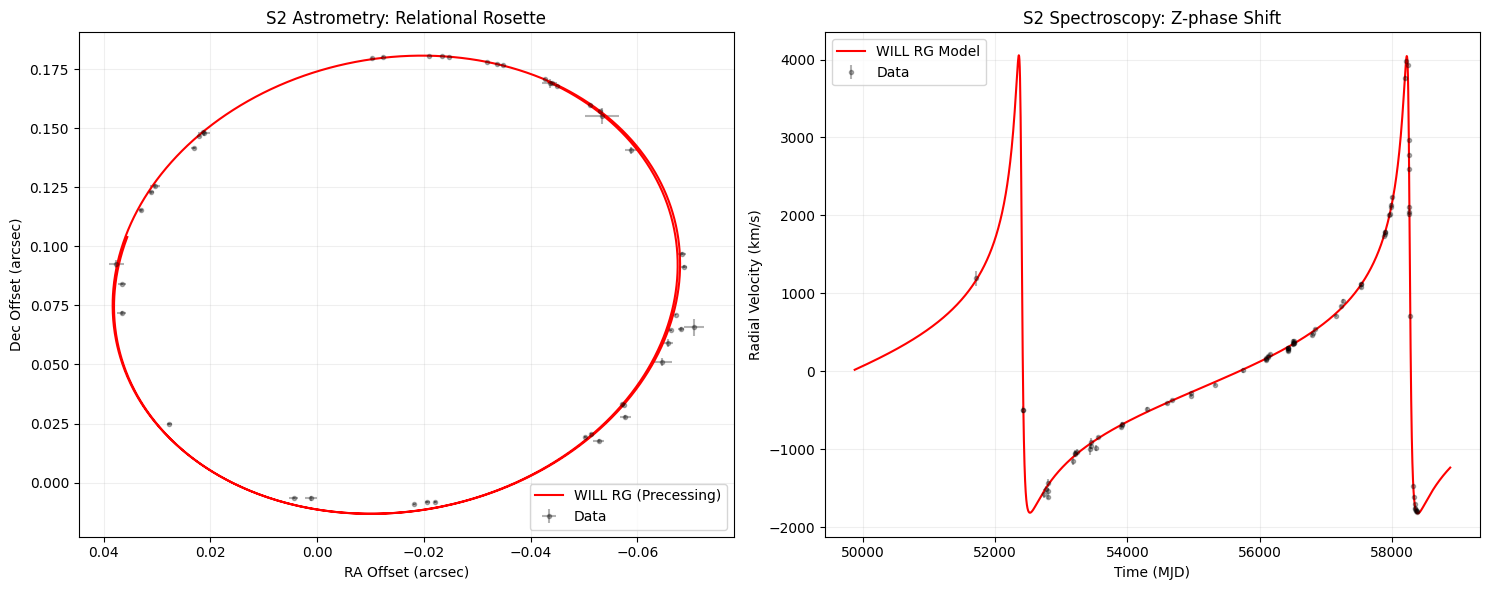

In [15]:
"""
WILL Relational Geometry: S2 Orbital Parametrization (R.O.M. Framework)
Author: Leibniz Partner & Anton Rize
Version: 1.4 (Strict Relational with Rømer Delay & Relational Redshift)

SCIENTIFIC STATEMENT:
Orbital dynamics and strong-field precession are not the result of masses
moving through curved background spacetime. In WILL Relational Geometry,
the exact trajectory and scale of the S2 system emerge purely from the
algebraic closure of its relational phase projections (kappa^2 = 2*beta^2).
"""

import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# --- 1. GLOBAL CONSTANTS ---
C_KMS = 299792.458
AU_KM = 149597870.7
MSUN_GM = (1.32712440018e20 / (C_KMS*1000)**2) / 1000

# --- 2. DATA LOADING (Raw URLs) ---
URL_ASTRO = 'https://raw.githubusercontent.com/AntonRize/WILL/main/DATA/aav8137_data_s2.csv'
URL_RV = 'https://raw.githubusercontent.com/AntonRize/WILL/main/DATA/S0-2_DataS1_full.csv'

print(">>> Loading raw data from GitHub...")
df_astro = pd.read_csv(URL_ASTRO).sort_values('mjd')
df_rv = pd.read_csv(URL_RV).sort_values('MJD')

m_a = df_astro['mjd'].values
x_obs, x_err = df_astro['x'].values, df_astro['xerr'].values
y_obs, y_err = df_astro['y'].values, df_astro['yerr'].values

m_r = df_rv['MJD'].values
rv_obs, rv_err = df_rv['RV_km_s'].values, df_rv['sigma_km_s'].values

# --- 3. RELATIONAL ALGORITHMS ---

def solve_kepler(M, e):
    E = np.copy(M)
    for _ in range(50):
        E = E - (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
    return E

def get_nu(mjd, T0, P, e):
    M = 2 * np.pi * (mjd - T0) / P
    orbits = np.floor(M / (2 * np.pi))
    M_mod = M % (2 * np.pi)
    E_mod = solve_kepler(M_mod, e)
    nu_mod = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E_mod / 2), np.sqrt(1 - e) * np.cos(E_mod / 2))
    return orbits * 2 * np.pi + (nu_mod % (2 * np.pi))

def will_model_strict(params, mjd_a, mjd_r):
    a_as, e, i, omega, Omega, P, T0, V0, K = params

    # [ALGEBRAIC LOCK & SCALE]
    beta_int = (K / C_KMS) / np.sin(i)
    beta_sq = (beta_int**2) * (1 - e**2)
    tau_Y_sq = 3 * beta_sq - 2 * (beta_sq**2)
    f_prec = tau_Y_sq / (1 - e**2)

    beta = np.sqrt(beta_sq)
    T_sec = P * 86400
    Rs_km = (T_sec * C_KMS * (beta**3)) / np.pi
    a_km = Rs_km / (2 * beta_sq)
    scale_km_per_as = a_km / a_as

    # --- ASTROMETRY WITH ROMER DELAY ---
    nu_a_0 = get_nu(mjd_a, T0, P, e)
    w_shift_a_0 = f_prec * nu_a_0
    r_O_0 = a_as * (1 - e**2) / (1 + e * np.cos(nu_a_0 - w_shift_a_0))
    z_km_a = r_O_0 * scale_km_per_as * np.sin(i) * np.sin(nu_a_0 + omega + w_shift_a_0)

    t_emit_a = mjd_a - z_km_a / (C_KMS * 86400)

    nu_a = get_nu(t_emit_a, T0, P, e)
    w_shift_a = f_prec * nu_a
    r_O = a_as * (1 - e**2) / (1 + e * np.cos(nu_a - w_shift_a))
    x_orb = r_O * np.cos(nu_a)
    y_orb = r_O * np.sin(nu_a)

    A = np.cos(Omega)*np.cos(omega) - np.sin(Omega)*np.sin(omega)*np.cos(i)
    B = np.sin(Omega)*np.cos(omega) + np.cos(Omega)*np.sin(omega)*np.cos(i)
    F = -np.cos(Omega)*np.sin(omega) - np.sin(Omega)*np.cos(omega)*np.cos(i)
    G = -np.sin(Omega)*np.sin(omega) + np.cos(Omega)*np.cos(omega)*np.cos(i)

    x_sky = B * x_orb + G * y_orb
    y_sky = A * x_orb + F * y_orb

    # --- RADIAL VELOCITY WITH ROMER & RELATIONAL REDSHIFT ---
    rv_pred = np.array([])
    if len(mjd_r) > 0:
        nu_r_0 = get_nu(mjd_r, T0, P, e)
        w_shift_r_0 = f_prec * nu_r_0
        r_O_r_0 = a_as * (1 - e**2) / (1 + e * np.cos(nu_r_0 - w_shift_r_0))
        z_km_r = r_O_r_0 * scale_km_per_as * np.sin(i) * np.sin(nu_r_0 + omega + w_shift_r_0)

        t_emit_r = mjd_r - z_km_r / (C_KMS * 86400)

        nu_r = get_nu(t_emit_r, T0, P, e)
        w_shift_r = f_prec * nu_r
        eff_w = omega + w_shift_r

        # 1. Classical Doppler z-projection
        vz_classical = K * (np.cos(nu_r + eff_w) + e * np.cos(eff_w))

        # 2. WILL Relational Redshift (Z_sys)
        r_km_r = a_km * (1 - e**2) / (1 + e * np.cos(nu_r - w_shift_r))
        kappa_o_sq = Rs_km / r_km_r
        beta_o_sq = kappa_o_sq - beta_sq
        v_relational = C_KMS * (kappa_o_sq + beta_o_sq) / 2

        rv_pred = V0 + vz_classical + v_relational

    return x_sky, y_sky, rv_pred, beta_sq, f_prec

def objective(p):
    xs, ys, rv, _, _ = will_model_strict(p, m_a, m_r)
    return np.sum(((x_obs-xs)/x_err)**2) + np.sum(((y_obs-ys)/y_err)**2) + np.sum(((rv_obs-rv)/rv_err)**2)

# --- 4. EXECUTE OPTIMIZATION ---
# Widened bounds to prevent trapping
p0 = [0.124, 0.885, 2.36, 1.15, 3.98, 5860, 58258, -10.0, 3000]
bounds = [(0.10, 0.15), (0.80, 0.95), (0, np.pi), (0, 2*np.pi), (0, 2*np.pi),
          (5800, 5950), (58100, 58400), (-200, 200), (1000, 5000)]

print(">>> Phase 1: Global search (Nelder-Mead)...")
res_nm = minimize(objective, p0, bounds=bounds, method='Nelder-Mead', options={'maxiter': 25000})

print(">>> Phase 2: Precision refinement (L-BFGS-B)...")
res = minimize(objective, res_nm.x, bounds=bounds, method='L-BFGS-B')

# --- 5. POST-FIT RELATIONAL DERIVATION ---
a_as, e, i, omega, Omega, P_days, T0, V0, K = res.x
chi2_val = res.fun
_, _, _, beta_sq, f_prec = will_model_strict(res.x, np.array([T0]), np.array([]))

beta = np.sqrt(beta_sq)
T_sec = P_days * 86400
Rs_km = (T_sec * C_KMS * (beta**3)) / np.pi
a_km = Rs_km / (2 * beta_sq)
a_au = a_km / AU_KM
R0_pc = (a_km / a_as) / 3.08567758e13 * (180*3600/np.pi)
Mass_Msun = (Rs_km / 2) / MSUN_GM

# --- 6. SCIENTIFIC OUTPUT ---
print("\n" + "="*65)
print("WILL RELATIONAL GEOMETRY: FULL OPTICAL + ROMER SOLUTION")
print("="*65)
print(f"Fit Quality (Chi-Squared):       {chi2_val:.4f}")
print(f"Number of Observables:           {len(x_obs)*2 + len(rv_obs)}")
print("-" * 65)
print(f"Relational Beta (beta):          {beta:.8f}")
print(f"Angular Semi-major Axis (a_as):  {a_as:.6f} arcsec")
print(f"Eccentricity (e):                {e:.6f}")
print(f"Inclination (i):                 {i:.6f} rad")
print(f"Argument of Periapsis (omega):   {omega:.6f} rad")
print(f"Period (T):                      {P_days:.4f} days")
print(f"Derived Precession (f_prec):     {f_prec:.8f}")
print(f"Systemic Velocity (V0):          {V0:.4f} km/s")
print("-" * 65)
print("DERIVED PHYSICAL PARAMETERS (FROM T and BETA ONLY):")
print(f"Schwarzschild Radius (Rs):       {Rs_km:.2f} km")
print(f"Semi-major Axis (a):             {a_au:.6f} AU")
print(f"Distance to Sgr A* (R0):         {R0_pc:.2f} pc")
print("-" * 65)
print(f"Final Calculated Mass (M):       {Mass_Msun/1e6:.4f} Million M_sun")
print("="*65)

# --- 7. PLOTTING ---
m_dense = np.linspace(min(m_a.min(), m_r.min()), max(m_a.max(), m_r.max()) + 500, 2000)
xs_d, ys_d, rv_d, _, _ = will_model_strict(res.x, m_dense, m_dense)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.errorbar(x_obs, y_obs, xerr=x_err, yerr=y_err, fmt='k.', alpha=0.3, label='Data')
plt.plot(xs_d, ys_d, 'r-', label='WILL RG (Precessing)')
plt.gca().invert_xaxis()
plt.xlabel('RA Offset (arcsec)')
plt.ylabel('Dec Offset (arcsec)')
plt.title('S2 Astrometry: Relational Rosette')
plt.legend()
plt.grid(True, alpha=0.2)

plt.subplot(1, 2, 2)
plt.errorbar(m_r, rv_obs, yerr=rv_err, fmt='k.', alpha=0.3, label='Data')
plt.plot(m_dense, rv_d, 'r-', label='WILL RG Model')
plt.xlabel('Time (MJD)')
plt.ylabel('Radial Velocity (km/s)')
plt.title('S2 Spectroscopy: Z-phase Shift')
plt.legend()
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [16]:
"""
High-Precision 1PN General Relativity Fit for S2 Orbit
Includes: Iterative Rømer & Shapiro delays, Gravitational Lensing, 1PN Precession, Relativistic Redshift.
"""

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.optimize import brentq
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Physical constants (SI units)
# ----------------------------------------------------------------------
C = 299792458.0
G = 6.67430e-11
MSUN = 1.98847e30
PC = 3.085677581e16
DAY = 86400.0
ARCSEC_TO_RAD = np.pi / (180.0 * 3600.0)
C_KMS = C / 1000.0

# ----------------------------------------------------------------------
# Load data
# ----------------------------------------------------------------------
url_astro = 'https://raw.githubusercontent.com/AntonRize/WILL/main/DATA/aav8137_data_s2.csv'
url_rv    = 'https://raw.githubusercontent.com/AntonRize/WILL/main/DATA/S0-2_DataS1_full.csv'

df_astro = pd.read_csv(url_astro).sort_values('mjd')
df_rv    = pd.read_csv(url_rv).sort_values('MJD')

t_astro = df_astro['mjd'].values
x_data  = df_astro['x'].values
x_err   = df_astro['xerr'].values
y_data  = df_astro['y'].values
y_err   = df_astro['yerr'].values

t_rv   = df_rv['MJD'].values
rv_data = df_rv['RV_km_s'].values
rv_err  = df_rv['sigma_km_s'].values

# ----------------------------------------------------------------------
# Kepler solver
# ----------------------------------------------------------------------
def solve_kepler(M, e):
    E = M + e * np.sin(M)
    for _ in range(20):
        E = E - (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
    return E

def true_anomaly(t, T0, P, e):
    M = 2 * np.pi * (t - T0) / P
    orbits = np.floor(M / (2 * np.pi))
    M_mod = M % (2 * np.pi)
    E = solve_kepler(M_mod, e)
    nu = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E/2), np.sqrt(1 - e) * np.cos(E/2))
    return orbits * 2 * np.pi + (nu % (2 * np.pi))

# ----------------------------------------------------------------------
# Core Kinematic Engine
# ----------------------------------------------------------------------
def get_orbit_state(t, a_m, e, i, omega0, Omega, P, T0, omega_dot):
    nu = true_anomaly(t, T0, P, e)
    M_mean = 2 * np.pi * (t - T0) / P
    omega = omega0 + omega_dot * M_mean

    r = a_m * (1 - e**2) / (1 + e * np.cos(nu))
    x_orb = r * np.cos(nu)
    y_orb = r * np.sin(nu)

    cos_O, sin_O = np.cos(Omega), np.sin(Omega)
    cos_w, sin_w = np.cos(omega), np.sin(omega)
    cos_i = np.cos(i)

    A = cos_O * cos_w - sin_O * sin_w * cos_i
    B = sin_O * cos_w + cos_O * sin_w * cos_i
    F = -cos_O * sin_w - sin_O * cos_w * cos_i
    G_TI = -sin_O * sin_w + cos_O * cos_w * cos_i

    # Z-axis projection for light travel time (z points toward observer)
    z = r * np.sin(nu + omega) * np.sin(i)

    # Sky coordinates
    x_sky = B * x_orb + G_TI * y_orb
    y_sky = A * x_orb + F * y_orb

    return x_sky, y_sky, z, r, nu, omega

# ----------------------------------------------------------------------
# Emission Time Solver (Rømer + Shapiro)
# ----------------------------------------------------------------------
def solve_emission_time(t_obs, a_m, e, i, omega0, Omega, P, T0, omega_dot, R_s):
    t_em = np.zeros_like(t_obs)
    for k, tobs in enumerate(t_obs):
        def objective(tem):
            _, _, z, r, _, _ = get_orbit_state(tem, a_m, e, i, omega0, Omega, P, T0, omega_dot)
            # Shapiro delay approximation: dt_shap = (2Rs/c) * ln(r + z)
            # Note: z is positive towards observer.
            t_shap = (2 * R_s / C) * np.log(np.abs(r + z) + 1e-10) / DAY
            t_romer = z / C / DAY
            return tem + t_romer + t_shap - tobs

        # Search brackets based on maximum expected delay
        try:
            t_em[k] = brentq(objective, tobs - 40.0, tobs + 40.0)
        except ValueError:
            t_em[k] = tobs # Fallback if objective fails to bracket
    return t_em

# ----------------------------------------------------------------------
# High-Precision GR Model
# ----------------------------------------------------------------------
def strict_gr_model(params, t_astro, t_rv):
    a_as, e, i, omega0, Omega, P, T0, V0, M_BH, R0_pc = params

    a_m = a_as * ARCSEC_TO_RAD * R0_pc * PC
    M_kg = M_BH * MSUN
    R_s = 2 * G * M_kg / C**2

    # 1PN Precession
    delta_omega_per_orbit = (3 * np.pi * R_s) / (a_m * (1 - e**2))
    omega_dot = delta_omega_per_orbit / (2 * np.pi)

    # Astrometry Execution
    x_sky_arcsec = np.array([])
    y_sky_arcsec = np.array([])

    if len(t_astro) > 0:
        t_em_astro = solve_emission_time(t_astro, a_m, e, i, omega0, Omega, P, T0, omega_dot, R_s)
        x_m, y_m, z_m, r_m, _, _ = get_orbit_state(t_em_astro, a_m, e, i, omega0, Omega, P, T0, omega_dot)

        # Convert base projection to arcsec
        D_m = R0_pc * PC
        x_base = x_m / D_m / ARCSEC_TO_RAD
        y_base = y_m / D_m / ARCSEC_TO_RAD

        # Gravitational Lensing Deflection Vector
        # d_theta = (2 Rs / D) * (theta / |theta|^2)
        theta_sq = x_base**2 + y_base**2
        lens_factor = (2 * R_s / D_m) / ARCSEC_TO_RAD
        dx_lens = lens_factor * x_base / (theta_sq + 1e-15)
        dy_lens = lens_factor * y_base / (theta_sq + 1e-15)

        x_sky_arcsec = x_base + dx_lens
        y_sky_arcsec = y_base + dy_lens

    # Radial Velocity Execution
    rv_pred = np.array([])
    if len(t_rv) > 0:
        t_em_rv = solve_emission_time(t_rv, a_m, e, i, omega0, Omega, P, T0, omega_dot, R_s)
        _, _, _, r_rv, nu_rv, omega_rv = get_orbit_state(t_em_rv, a_m, e, i, omega0, Omega, P, T0, omega_dot)

        # Keplerian velocity semi-amplitude K
        K_amp = np.sqrt(G * M_kg / (a_m * (1 - e**2))) * np.sin(i)
        v_rad = K_amp * (np.cos(nu_rv + omega_rv) + e * np.cos(omega_rv))
        rv_kepler = V0 + v_rad / 1000.0

        # Exact 1PN Redshifts
        v2 = G * M_kg * (2.0 / r_rv - 1.0 / a_m)
        z_grav = G * M_kg / (r_rv * C**2)
        z_td   = 0.5 * v2 / C**2

        rv_pred = rv_kepler + C_KMS * (z_grav + z_td)

    return x_sky_arcsec, y_sky_arcsec, rv_pred

# ----------------------------------------------------------------------
# Objective Function
# ----------------------------------------------------------------------
def chi2(params):
    x_mod, y_mod, rv_mod = strict_gr_model(params, t_astro, t_rv)
    chi2_astro = np.sum(((x_data - x_mod) / x_err)**2 + ((y_data - y_mod) / y_err)**2)
    chi2_rv = np.sum(((rv_data - rv_mod) / rv_err)**2)
    return chi2_astro + chi2_rv

# ----------------------------------------------------------------------
# Initialization and Execution
# ----------------------------------------------------------------------
p0 = [
    0.125,       # a (arcsec)
    0.88,        # e
    2.34,        # i (rad)
    1.13,        # ω0 (rad)
    3.96,        # Ω (rad)
    5844.0,      # P (days)
    58250.0,     # T0 (MJD)
    0.0,         # V0 (km/s)
    4.3e6,       # M_BH (Msun)
    8000.0       # R0 (pc)
]

bounds = [
    (0.05, 0.3), (0.7, 0.99), (0, np.pi), (0, 2*np.pi), (0, 2*np.pi),
    (5000, 6500), (58000, 58500), (-200, 200),
    (3.5e6, 5.5e6), (7500, 9000)
]

print("Executing High-Precision GR Integration (1PN + Shapiro + Lensing)...")
res = minimize(chi2, p0, bounds=bounds, method='Nelder-Mead', options={'maxiter': 5000})
res = minimize(chi2, res.x, bounds=bounds, method='L-BFGS-B')

a_as, e, i, omega0, Omega, P, T0, V0, M_BH, R0_pc = res.x
a_m = a_as * ARCSEC_TO_RAD * R0_pc * PC
delta_omega = (6 * np.pi * G * M_BH * MSUN) / (C**2 * a_m * (1 - e**2))

print("\n" + "="*60)
print("HIGH-PRECISION GR FIT – S2 ORBIT")
print("="*60)
print(f"χ² = {res.fun:.2f}")
print("-"*60)
print(f"Semi-major axis a   = {a_as:.6f} arcsec")
print(f"Eccentricity e      = {e:.6f}")
print(f"Inclination i       = {i:.6f} rad")
print(f"Arg. of periapsis ω = {omega0:.6f} rad")
print(f"Long. asc. node Ω   = {Omega:.6f} rad")
print(f"Period P            = {P:.4f} days")
print(f"Periapsis epoch T0  = {T0:.4f} MJD")
print(f"Systemic velocity   = {V0:.4f} km/s")
print(f"Black hole mass     = {M_BH/1e6:.4f} × 10⁶ M☉")
print(f"Distance R0         = {R0_pc:.2f} pc")
print("="*60)

Executing High-Precision GR Integration (1PN + Shapiro + Lensing)...

HIGH-PRECISION GR FIT – S2 ORBIT
χ² = 969.17
------------------------------------------------------------
Semi-major axis a   = 0.124299 arcsec
Eccentricity e      = 0.887964
Inclination i       = 2.370777 rad
Arg. of periapsis ω = 1.158446 rad
Long. asc. node Ω   = 3.985350 rad
Period P            = 5862.4710 days
Periapsis epoch T0  = 58257.4394 MJD
Systemic velocity   = -15.3389 km/s
Black hole mass     = 4.6075 × 10⁶ M☉
Distance R0         = 8999.68 pc
